In [1]:
%cd ../../

/home/hoanghu/projects/fw-models


In [2]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import TargetEncoder, OrdinalEncoder
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [3]:
plt.style.use('seaborn-v0_8')
plt.rcParams.update({'font.size': 8})

# Load data and resources

## dim `meals`

In [4]:
meals = pl.read_excel("data/processed/phase_4/dim_meals.xlsx")
meals.head()

meal_id,meal_type_1,schoolyear,is_kela,is_new,restaurant,meal_type_2,pcs_mean
i64,str,str,bool,bool,str,str,f64
9017,"""vegan""","""24-25""",true,true,"""che-exa-vik""","""vegan-miscellaneous""",116.3425
7201,"""vegan""","""23-24""",false,false,null,null,106.231119
9032,"""vegan""","""23-24""",false,false,null,null,106.231119
9102,"""vegan""","""23-24""",false,false,null,null,106.231119
7010,"""vegetarian""","""24-25""",false,false,"""che-exa-vik""",null,71.0


## dim `opentime`

In [5]:
dim_opentime = (
    pl
    .from_records([
        {'restaurant': 'che', 'time_open': '10:30', 'time_close': '15:00'},
        {'restaurant': 'exa', 'time_open': '11:00', 'time_close': '14:00'},
        {'restaurant': 'phy', 'time_open': '10:00', 'time_close': '15:00'},
        {'restaurant': 'vik', 'time_open': '10:30', 'time_close': '14:00'},
    ])
    .select(
        'restaurant',
        pl.col('time_open').str.to_datetime("%H:%M"),
        pl.col('time_close').str.to_datetime("%H:%M")
    )
    .with_columns(
        ((pl.col('time_close') - pl.col('time_open')).dt.total_minutes() / 60.).alias('working_duration')
    )
)

dim_opentime.head()

restaurant,time_open,time_close,working_duration
str,datetime[μs],datetime[μs],f64
"""che""",0001-01-01 10:30:00,0001-01-01 15:00:00,4.5
"""exa""",0001-01-01 11:00:00,0001-01-01 14:00:00,3.0
"""phy""",0001-01-01 10:00:00,0001-01-01 15:00:00,5.0
"""vik""",0001-01-01 10:30:00,0001-01-01 14:00:00,3.5


## dim `meal_names`

In [6]:
meal_names = pl.read_excel("data/processed/phase_4/dim_meal_names.xlsx")
meal_names.head()

meal_id,meal
i64,str
9017,"""""Butter"" härkäpapua & pähkinää"""
7201,"""2023 Härkäpu-sienilasagnette"""
9032,"""Appelisiini-luomukikhernecurry…"
9102,"""Artisokkavugetteja & tuoretoma…"
7010,"""Aurajuusto-pinaattilasagnette"""


## raw POS data

In [7]:
paths = [
    "data/raw/pos/Sold lunches.csv",
    "data/raw/pos/Sold lunches Kumpula 6-8 2024.csv",
    "data/raw/pos/Sold lunches Kumpula 9-10 2024.csv",
    "data/raw/pos/Sold lunches Viikuna 2023.csv",
    "data/raw/pos/Sold lunches Viikuna 2024.csv"
]

raw = []
for path in paths:
    df = pl.read_csv(path, separator=';', has_header=False, skip_rows=1)
    # df.columns = np.arange(df.shape[1], dtype=str)
    raw.append(df)


pos = pl.concat(raw)
pos.head()

column_1,column_2,column_3,column_4,column_5,column_6,column_7
str,str,str,str,str,i64,str
"""2.1.2023""","""10:31""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:32""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",1,"""0,9"""
"""2.1.2023""","""10:35""","""600 Chemicum""","""Kala""","""Kalapuikot tillikermaviilikast""",1,"""1,04"""
"""2.1.2023""","""10:36""","""600 Chemicum""","""Liha""","""Uunimakkaraa,sinappikastiketta""",2,"""1,8"""


## Pre-process data

In [8]:
# Rename columns
pos.columns = ['date', 'time', 'restaurant', 'meal_type', 'meal', 'pcs', 'co2']



# Convert pcs
pos = pos.filter((pl.col('pcs').is_not_null()) & (pl.col('pcs') >= 0))


# Map restaurant name
names_restaurant = {
    '600 Chemicum': 'che', #'chemicum',
    '610 Physicum': 'phy', #'physicum',
    '620 Exactum': 'exa', #'exactum'
    '570 Viikuna': 'vik',
}
pos = pos.with_columns(pl.col('restaurant').replace_strict(names_restaurant))


# Process date
pos = (
    pos
    .with_columns(
        (pl.col('date') + " " + pl.col('time')).str.to_datetime("%d.%m.%Y %H:%M").alias('datetime')
    )
    .drop('date', 'time')
)


# Process meal
pos = (
    pos

    # Remove trailing spaces
    .with_columns(
        pl.col('meal').str.strip_chars(' ')
    )

    
    # Get meal_id
    .join(meal_names, on='meal', how='left')

    
    # Remove entries having no `meal_id`
    .filter(pl.col('meal_id').is_not_null())
)



# Aggregate by date and supplement serving duration per day
pos = (
    pos
    .group_by('restaurant', pl.col('datetime').dt.date().alias('date'), 'meal_id')
    .agg(
        pl.col('pcs').sum(),
        pl.col('datetime').min().alias('time_start'),
        pl.col('datetime').max().alias('time_end'),
    )
    .with_columns(
        ((pl.col('time_end') - pl.col('time_start')).dt.total_minutes() / 60.).alias('serving_duration')
    )
    .join(
        dim_opentime.select('restaurant', 'working_duration'),
        on='restaurant',
        how='left'
    )
    .with_columns(
        (pl.col('serving_duration') / pl.col('working_duration')).alias('serving_percent')
    )
)



# Remove redundant columns
pos = pos.drop('time_start', 'time_end', 'serving_duration', 'working_duration')


# Add meal_type
meal_types = meals.select(
    'meal_id',
    pl.col('meal_type_1').alias('meal_type')
)
pos = pos.join(meal_types, on='meal_id', how='left')



# Ignore buffet
pos = pos.filter(pl.col('meal_type') != pl.lit('buffet'))


pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type
str,date,i64,i64,f64,str
"""phy""",2023-11-29,1515,9,0.436667,"""meat"""
"""che""",2023-08-10,9500143,174,0.807407,"""fish"""
"""phy""",2023-02-15,6096,7,0.74,"""vegan"""
"""che""",2023-02-23,7005,68,0.833333,"""vegan"""
"""phy""",2024-04-30,2093,1,0.0,"""vegetarian"""


## Encode

In [9]:
pos = (
    pos
    # .filter((pl.col('meal_id') == 9500151) & (pl.col('restaurant') == "che"))
    .with_columns(
        pl.col('date').rank(descending=True).over(['restaurant', 'meal_id'], order_by='date').alias('rank')
    )
)
pos_train = pos.filter(pl.col('rank') > 1).drop('rank')

In [10]:
# Encode restaurant
enc_restaurant = OrdinalEncoder()
enc_restaurant.fit(pos.select('restaurant'))
pos = pos.with_columns(
    pl.Series('restaurant_enc', values=enc_restaurant.transform(pos.select('restaurant'))).arr.first().cast(pl.Int32),
)



# Encode meal type
enc_meal_type = OrdinalEncoder()
enc_meal_type.fit(pos.select('meal_type'))
pos = pos.with_columns(
    pl.Series('meal_type_enc', values=enc_meal_type.transform(pos.select('meal_type'))).arr.first().cast(pl.Int32),
)


# Encode meal_id
enc_meal_id = TargetEncoder(target_type='continuous')
enc_meal_id.fit(pos_train.select('meal_id'), pos_train.get_column('pcs'))
pos = pos.with_columns(
    pl.Series('meal_id_enc', values=enc_meal_id.transform(pos.select('meal_id'))).arr.first(),
)



pos.head()

restaurant,date,meal_id,pcs,serving_percent,meal_type,rank,restaurant_enc,meal_type_enc,meal_id_enc
str,date,i64,i64,f64,str,f64,i32,i32,f64
"""phy""",2023-11-29,1515,9,0.436667,"""meat""",63.0,2,2,13.854412
"""che""",2023-08-10,9500143,174,0.807407,"""fish""",12.0,0,1,146.134086
"""phy""",2023-02-15,6096,7,0.74,"""vegan""",176.0,2,3,14.339404
"""che""",2023-02-23,7005,68,0.833333,"""vegan""",1.0,0,3,38.743866
"""phy""",2024-04-30,2093,1,0.0,"""vegetarian""",37.0,2,4,5.841332


## Supplement features

In [11]:
# pos = (
#     pos
#     # .filter((pl.col('meal_id') == 9500151) & (pl.col('restaurant') == "che"))
#     .with_columns(
#         pl.col('pcs').cum_sum().over(['restaurant', 'meal_id'], order_by='date').alias('cum_sum'),
#         pl.col('pcs').cum_count().over(['restaurant', 'meal_id'], order_by='date').alias('cum_count'),
#     )
#     .with_columns(
#         (pl.col('cum_sum') / pl.col('cum_count')).shift(1).over(['restaurant', 'meal_id'], order_by='date').alias('cum_mean_lag')
#     )
#     .drop('cum_sum', 'cum_count')
#     .filter(pl.col('cum_mean_lag').is_not_null())
#     # .sort('date')
# )

# pos.head()

# Train

In [12]:


pos_val = pos.filter(pl.col('rank') == 1).drop('rank').to_pandas()
pos_train = pos.filter(pl.col('rank') > 1).drop('rank').to_pandas()

pos_train.head()

,restaurant,date,meal_id,pcs,serving_percent,meal_type,restaurant_enc,meal_type_enc,meal_id_enc
0,phy,2023-11-29,1515,9,0.436667,meat,2,2,13.854412
1,che,2023-08-10,9500143,174,0.807407,fish,0,1,146.134086
2,phy,2023-02-15,6096,7,0.740000,vegan,2,3,14.339404
3,phy,2024-04-30,2093,1,0.000000,vegetarian,2,4,5.841332
4,phy,2023-04-21,6137,7,0.636667,vegan,2,3,14.073227


In [13]:
cols_X = [
    'meal_id_enc',
    'restaurant_enc',
    'meal_type_enc',
    'serving_percent',
    # 'cum_mean_lag'
]
col_y = 'pcs'
cols_cat = [
    # 'meal_id_enc',
    'restaurant_enc',
    'meal_type_enc',
]

Xtrain, ytrain = pos_train[cols_X], pos_train[col_y]
Xval, yval = pos_val[cols_X], pos_val[col_y]

Xtrain.head()

,meal_id_enc,restaurant_enc,meal_type_enc,serving_percent
0,13.854412,2,2,0.436667
1,146.134086,0,1,0.807407
2,14.339404,2,3,0.740000
3,5.841332,2,4,0.000000
4,14.073227,2,3,0.636667


In [14]:
models = {
    'HistGB':   {'model': HistGradientBoostingRegressor(categorical_features=cols_cat), 'is_cat': True},
    'XGB-cat':  {'model': XGBRegressor(tree_method="hist", enable_categorical=True), 'is_cat': True},
    'CatBoost': {'model': CatBoostRegressor(verbose=False, cat_features=cols_cat), 'is_cat': True},
    'LBGM-cat': {'model': LGBMRegressor(verbose=0), 'is_cat': True},

    # 'RF':       {'model': RandomForestRegressor(n_jobs=-1), 'is_cat': False},
    # 'LBGM':     {'model': LGBMRegressor(verbose=0), 'is_cat': False},
    # 'XGB':      {'model': XGBRegressor(), 'is_cat': False},
}

for name, model in models.items():
    print(f"Start: {name}")

    X = Xtrain.copy()

    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    if name == 'LBGM-cat':
        kwargs = dict(categorical_feature=cols_cat)
    else:
        kwargs = {}
    model['model'].fit(X, ytrain, **kwargs)

Start: HistGB


Start: XGB-cat
Start: CatBoost
Start: LBGM-cat


== Split: val
Start: HistGB


Start: XGB-cat
Start: CatBoost
Start: LBGM-cat
== Split: train
Start: HistGB
Start: XGB-cat
Start: CatBoost
Start: LBGM-cat


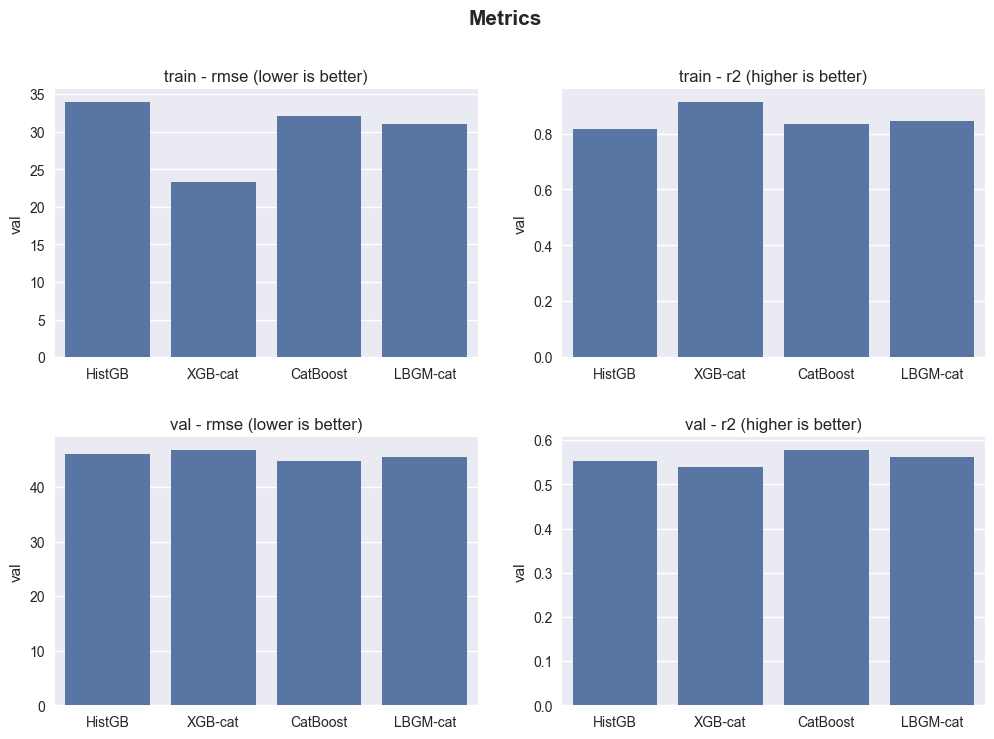

In [15]:
metrics_models = []

def calc_metrics(split: pd.DataFrame, model: dict, verbose: bool = False) -> tuple:
    X = split[cols_X].copy()
    if model['is_cat'] is True:
        for col in cols_cat:
            X[col] = X[col].astype('category')

    split['pcs_pred'] = np.clip(model['model'].predict(X), a_min=0, a_max=None)
    # split = (
    #     split
    #     .groupby(['date', 'restaurant', 'meal_id', 'meal_type'])
    #     .agg({'pcs': 'mean', 'pcs_pred': 'mean'})
    #     .reset_index()
    # )
    
    
    rmse = root_mean_squared_error(split['pcs'], split['pcs_pred']).item()
    r2 = r2_score(split['pcs'], split['pcs_pred'])

    if verbose is True:
        print(f"rmse: {rmse:.4f}")
        print(f"r2  : {r2:.4f}")

    return rmse, r2

print("== Split: val")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_val, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'val', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'val', 'metric': 'r2'})


print("== Split: train")
for name, model in models.items():
    print(f"Start: {name}")

    rmse, r2 = calc_metrics(pos_train, model)
    metrics_models.append({'model': name, 'val': rmse, 'split': 'train', 'metric': 'rmse'})
    metrics_models.append({'model': name, 'val': r2, 'split': 'train', 'metric': 'r2'})



# Visualize
metrics = pd.DataFrame.from_records(metrics_models)

fig = plt.figure(figsize=(12, 8))
fig.suptitle("Metrics", fontsize=15, fontweight='bold')
fig.subplots_adjust(wspace=0.2, hspace=0.3)

for i, (split, metric) in enumerate(product(['train', 'val'], ['rmse', 'r2'])):
    df = metrics[(metrics['split'] == split) & (metrics['metric'] == metric)]

    ax = fig.add_subplot(2, 2, i+1)
    sns.barplot(df, x='model', y='val', ax=ax)
    description = "lower" if metric == "rmse" else "higher"
    ax.set_title(f"{split} - {metric} ({description} is better)")
    ax.set_xlabel("")


<Axes: xlabel='importance', ylabel='name'>

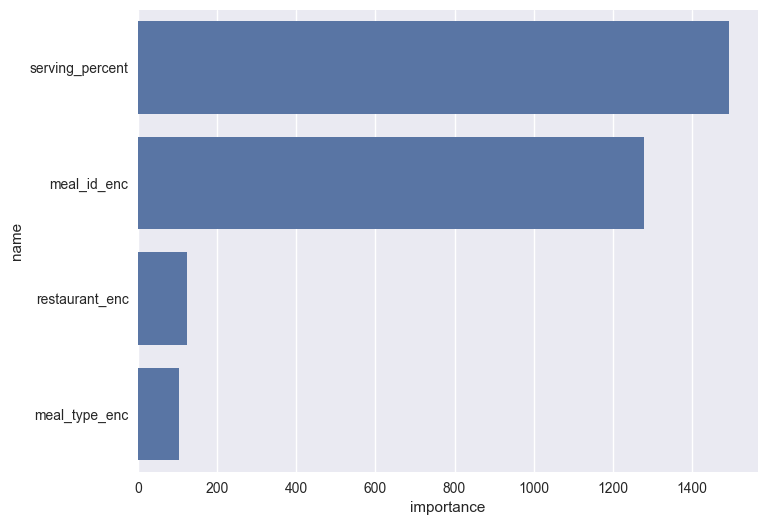

In [16]:
feat_imp = pd.DataFrame({
    'name': Xtrain.columns,
    'importance': models['LBGM-cat']['model'].feature_importances_
})

feat_imp.sort_values(by='importance', ascending=False, inplace=True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
sns.barplot(feat_imp[:10], y='name', x='importance', ax=ax)

In [17]:
pos_val

,restaurant,date,meal_id,pcs,serving_percent,meal_type,restaurant_enc,meal_type_enc,meal_id_enc,pcs_pred
0,che,2023-02-23,7005,68,0.833333,vegan,0,3,38.743866,57.990932
1,exa,2023-09-04,6324,2,0.127778,fish,1,1,54.807066,9.323421
2,exa,2024-10-04,6159,40,0.983333,vegan,1,3,134.782036,127.726799
3,exa,2024-10-17,9500056,203,1.022222,fish,1,1,88.286100,136.589157
4,exa,2024-09-05,6558,10,0.433333,vegan,1,3,32.725766,17.081842
...,...,...,...,...,...,...,...,...,...,...
687,che,2024-10-31,1307,138,0.981481,vegan,0,3,59.533808,122.352405
688,vik,2023-08-22,1119,6,0.495238,vegetarian,3,4,54.807066,26.761904
689,che,2024-04-26,7609,17,0.422222,fish,0,1,55.672979,21.793806
690,che,2024-09-11,894,8,0.000000,fish,0,1,54.807066,12.590166
